In [312]:
import pandas as pd
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np

In [313]:
df = pd.read_csv('..\\data\\segment2.csv')
df.head()

,lat,long,age,q_ihfc,q_ps,q_stein,ps_z,stein_z
0,48.7500,-127.75,2.906279,200.0,277.518538,299.158617,3096.673436,3222.245155
1,47.8983,-127.20,4.359262,161.0,226.597009,244.266377,3230.759601,3362.077870
2,47.8983,-127.65,3.190760,304.0,264.858297,285.511167,3125.194460,3251.988508
3,48.6833,-126.87,5.543758,60.8,200.936360,216.604786,3324.081515,3459.399294
4,48.6850,-126.87,5.543758,63.7,200.936360,216.604786,3324.081515,3459.399294


note that y = df[['ps_q']] will make the shape (#,#) but y = df['ps_q'] will make the shape (#,)

In [335]:
x = df.drop(columns=['q_ihfc','ps_z', 'stein_z', 'q_stein'])
y = df['ps_z']

In [336]:
x.head()

,lat,long,age,q_ps
0,48.7500,-127.75,2.906279,277.518538
1,47.8983,-127.20,4.359262,226.597009
2,47.8983,-127.65,3.190760,264.858297
3,48.6833,-126.87,5.543758,200.936360
4,48.6850,-126.87,5.543758,200.936360


In [316]:
x.shape

(3691, 2)

In [317]:
y.head()

0    3096.673436
1    3230.759601
2    3125.194460
3    3324.081515
4    3324.081515
Name: ps_z, dtype: float64

In [318]:
ts = 0.2

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=ts)

In [319]:
x_train.shape

(2952, 2)

this is the raw validation data

In [320]:
x_test.shape

(739, 2)

In [321]:
x_train.describe().round(3)

,lat,long
count,2952.000,2952.000
mean,48.176,-128.316
std,0.323,0.661
min,47.686,-129.505
25%,47.887,-128.710
50%,48.330,-128.640
75%,48.455,-127.785
max,48.997,-126.223


In [322]:
x_test.describe().round(3)

,lat,long
count,739.000,739.000
mean,48.149,-128.316
std,0.319,0.648
min,47.686,-129.260
25%,47.867,-128.710
50%,48.136,-128.640
75%,48.454,-127.786
max,48.900,-126.223


In [323]:
train_data = lgb.Dataset(x_train, label = y_train)
test_data = lgb.Dataset(x_test, label = y_test)

In [324]:
lr = 0.1

params = {
    'objective':'regression',
    'metric':'rmse',
    'boosting_type':'gbdt',
    'learning_rate':lr,
    'verbose':1
}

In [325]:
nbr = 100
model = lgb.train(params, train_data, valid_sets = [test_data], num_boost_round=nbr)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000108 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 2952, number of used features: 2
[LightGBM] [Info] Start training from score 2918.704344


In [326]:
y_pred = model.predict(x_test)

In [327]:
y_pred.shape

(739,)

In [328]:
y_pred, y_pred.shape

(array([2769.17661566, 2854.37115772, 2748.105347  , 3111.29210045,
        2833.97972077, 3142.40273682, 2705.52251086, 2769.25592511,
        2704.40473282, 3131.06553875, 2764.9548308 , 3161.93698321,
        2878.27313605, 2562.07910576, 2769.25592511, 2748.94192849,
        2769.25528891, 2769.25528891, 3093.47470773, 2770.03709699,
        2811.51364973, 3233.83456018, 3131.06553875, 3374.34231647,
        3125.21742546, 2916.48384473, 2834.18906477, 2754.522279  ,
        2769.25592511, 3378.09433846, 2878.11550261, 3338.51080246,
        2916.86592506, 3192.78547977, 3251.32992611, 3131.06553875,
        2640.27348127, 2769.25528891, 3373.87440592, 3259.32272772,
        2560.41124516, 2878.22950391, 3131.06553875, 2871.64930827,
        2754.40781893, 3322.20676312, 2877.41665985, 3125.14322958,
        3183.42260174, 3131.06553875, 3125.14322958, 2825.94425885,
        2846.04932353, 2558.24451373, 3324.27927316, 2755.06803019,
        2785.27986531, 2770.5408253 , 2756.81356

In [329]:
residuals = y_test - y_pred

negative mean: overpredicting

In [330]:
residuals.head(), residuals.describe()

(2937     0.026371
 1442   -64.597322
 433     -0.244601
 2124    -3.764040
 1420    -5.633963
 Name: ps_z, dtype: float64,
 count    739.000000
 mean       0.568430
 std       13.088251
 min      -69.970887
 25%       -0.273690
 50%        0.015423
 75%        0.135812
 max      163.924785
 Name: ps_z, dtype: float64)

In [331]:
dfr = pd.DataFrame({
    'long': x_test['long'].values,
    'lat': x_test['lat'].values,
    'ps_q_test_data': y_test,
    'ps_q_predicted': y_pred,
    'residual': residuals
})

saving both the csv file and a text file of specified parameters

In [332]:
pd.DataFrame(dfr).to_csv('..\\created_data\\seg2_ps_z_residuals.csv', index=False)

with open('..\\created_data\\seg2_ps_z_params.txt', 'w') as f:
    f.write('saving parameters for this dataset...\n')
    f.write(f'learning rate: {lr}\nnum_boost_rate: {nbr}\ntest size: {ts}\n')
    f.write(f'gives mean of: {residuals.mean()}')

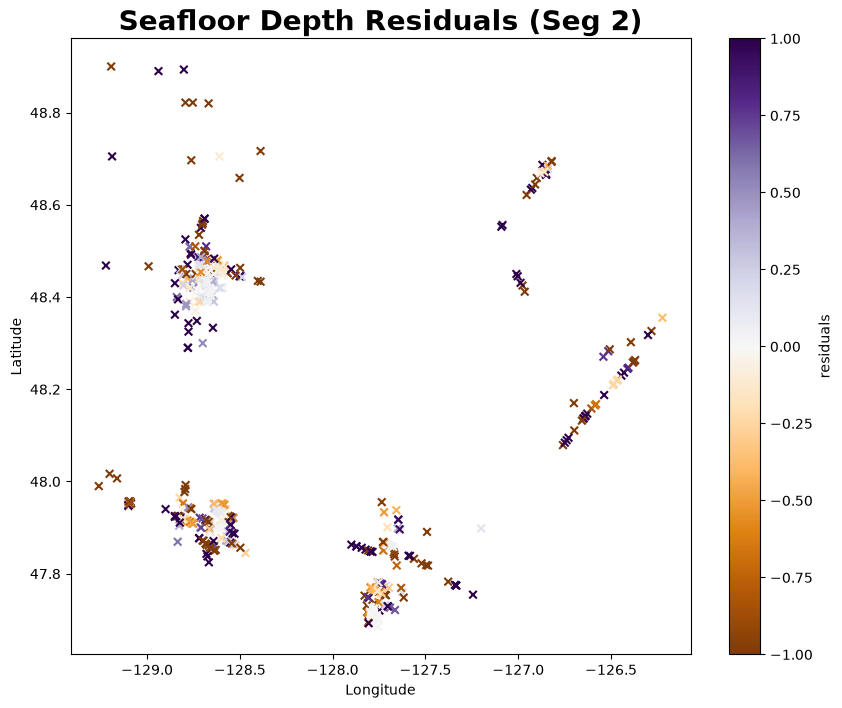

In [333]:
plt.figure(figsize=(10, 8))
plt.scatter(x_test['long'], x_test['lat'], c=residuals, cmap='PuOr',
            marker='x', s=30, vmin=-1, vmax=1)
plt.colorbar(label='residuals')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Seafloor Depth Residuals (Seg 2)', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})

plt.savefig('..\\figs\\res_ps_z_seg2.png', dpi=400)
plt.show()